In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

## Load Data

In [31]:
# If running on colab you can download the data using gdown. Uncomment the below code. 

import gdown
!gdown 1JTvMkEaR3AxqAagYzfLebnS_RavA7agR #x_train_img.npz
!gdown 1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1 #x_test_img.npz
!gdown 1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0 #x_train.csv
!gdown 1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8 #x_test.csv
!gdown 1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg #y_train.csv

Downloading...
From (original): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR
From (redirected): https://drive.google.com/uc?id=1JTvMkEaR3AxqAagYzfLebnS_RavA7agR&confirm=t&uuid=8f55b176-2d31-4844-940f-42823a33e64c
To: /content/x_train_img.npz
100% 177M/177M [00:01<00:00, 144MB/s]  
Downloading...
From (original): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1
From (redirected): https://drive.google.com/uc?id=1bQxyUXwvUn2cPjb5gIp-jB3CUpqD4Ca1&confirm=t&uuid=9bd3fa2e-2e12-4293-a270-dae74b7cd91c
To: /content/x_test_img.npz
100% 49.0M/49.0M [00:00<00:00, 91.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1tED7-ZgWT0ONtohOD1BCCrlTvXfQM6L0
To: /content/x_train.csv
100% 160k/160k [00:00<00:00, 71.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k36wEmeaks1pg2Q5t3aW3e24uxDaUll8
To: /content/x_test.csv
100% 40.2k/40.2k [00:00<00:00, 62.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1J2fEdFSfZnTJ9YwxNnB8qDEOrIOkqbkg
To: /cont

In [32]:
img_file = "x_train_img.npz"
metadata_file = "x_train.csv"
y_file = "y_train.csv"

In [33]:
X_dev = pd.read_csv(metadata_file)
y_dev = pd.read_csv(y_file)
X_dev

,patient_id,img_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,region,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation
0,PAT_620,PAT_620_001,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,True,3.0,NECK,6.0,5.0,True,True,False,True,True,True
1,PAT_388,PAT_388_002,False,True,POMERANIA,POMERANIA,79,False,MALE,True,False,False,False,1.0,FOREARM,5.0,5.0,True,True,False,False,True,True
2,PAT_518,PAT_518_003,False,True,GERMANY,ITALY,52,False,FEMALE,False,True,True,True,3.0,FACE,15.0,10.0,False,True,False,True,True,True
3,PAT_635,PAT_635_004,False,False,POMERANIA,POMERANIA,74,True,FEMALE,False,False,False,False,1.0,FACE,15.0,10.0,True,True,True,False,True,True
4,PAT_447,PAT_447_005,False,True,GERMANY,GERMANY,58,True,FEMALE,True,True,True,True,1.0,FOREARM,9.0,7.0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,True,False,POMERANIA,POMERANIA,66,False,MALE,True,False,True,True,2.0,EAR,20.0,15.0,True,False,True,False,True,True
1174,PAT_640,PAT_640_1471,False,False,POMERANIA,POMERANIA,41,True,MALE,False,False,False,False,2.0,FACE,9.0,5.0,True,UNK,True,UNK,True,True
1175,PAT_539,PAT_539_1472,False,False,POMERANIA,POMERANIA,43,True,FEMALE,True,True,False,False,2.0,FACE,9.0,5.0,True,UNK,False,UNK,True,True
1176,PAT_620,PAT_620_1473,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,True,3.0,CHEST,13.0,12.0,True,True,False,True,False,False


In [34]:
#print the first 5 rows and all columns 
# Source - https://stackoverflow.com/a/47022213
# Posted by Isma, modified by community. See post 'Timeline' for change history
# Retrieved 2026-04-09, License - CC BY-SA 4.0

import pandas as pd
from IPython.display import display

pd.options.display.max_columns = None
display(X_dev.head())



,patient_id,img_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,region,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation
0,PAT_620,PAT_620_001,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,True,3.0,NECK,6.0,5.0,True,True,False,True,True,True
1,PAT_388,PAT_388_002,False,True,POMERANIA,POMERANIA,79,False,MALE,True,False,False,False,1.0,FOREARM,5.0,5.0,True,True,False,False,True,True
2,PAT_518,PAT_518_003,False,True,GERMANY,ITALY,52,False,FEMALE,False,True,True,True,3.0,FACE,15.0,10.0,False,True,False,True,True,True
3,PAT_635,PAT_635_004,False,False,POMERANIA,POMERANIA,74,True,FEMALE,False,False,False,False,1.0,FACE,15.0,10.0,True,True,True,False,True,True
4,PAT_447,PAT_447_005,False,True,GERMANY,GERMANY,58,True,FEMALE,True,True,True,True,1.0,FOREARM,9.0,7.0,False,True,False,False,False,False


In [35]:
# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")  
    return img, ids

imgs, img_ids = load_img_data(img_file)
print(img_ids.shape, imgs.shape)

# Make sure the IDs match and are in the same order
assert np.all(img_ids == X_dev['img_id']), "Image IDs in metadata and image data do not match"

Successfully loaded 1178 images.
(1178,) (1178, 256, 256, 3)


<Axes: xlabel='count', ylabel='fine_label'>

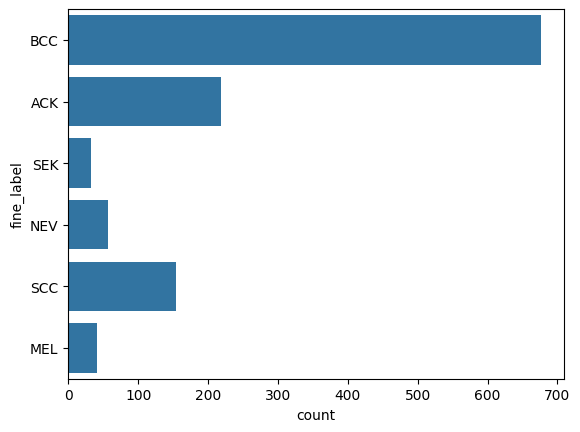

In [36]:
# Plot the class balance
sns.countplot(y_dev["fine_label"])

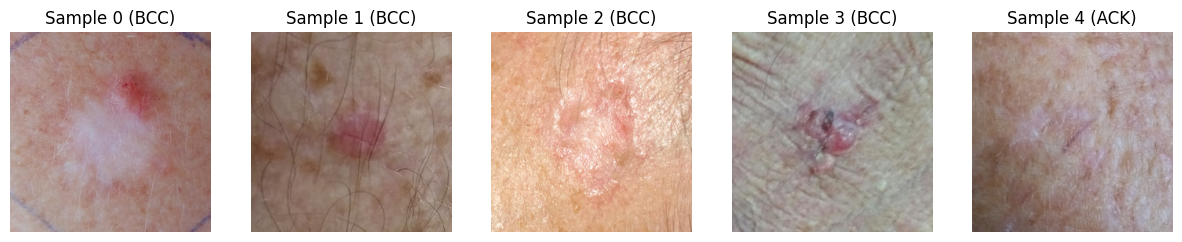

In [37]:
# Show the first 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    axes[i].imshow(imgs[i])
    axes[i].axis('off')
    axes[i].set_title(f"Sample {i} ({y_dev.iloc[i]['fine_label']})")

plt.show()


In [ ]:
# save sample images in folder for checking the lesion caracteristics
import os
os.makedirs("sample_images", exist_ok=True)
#List of indexes for each lesion type
BCC_indexes = y_dev[y_dev['fine_label'] == "BCC"].index
MEL_indexes = y_dev[y_dev['fine_label'] == "MEL"].index
ACK_indexes = y_dev[y_dev['fine_label'] == "ACK"].index
SEK_indexes = y_dev[y_dev['fine_label'] == "SEK"].index
NEV_indexes = y_dev[y_dev['fine_label'] == "NEV"].index
SCC_indexes = y_dev[y_dev['fine_label'] == "SCC"].index

print(f"Number of BCC samples: {len(BCC_indexes)}")
print(f"Number of MEL samples: {len(MEL_indexes )}")
print(f"Number of ACK samples: {len(ACK_indexes)}")
print(f"Number of SEK samples: {len(SEK_indexes)}")
print(f"Number of NEV samples: {len(NEV_indexes)}")
print(f"Number of SCC samples: {len(SCC_indexes)}")

# save 30 images of each lesion type

# for i, idx in enumerate(BCC_indexes[:30]):
#     plt.imsave(f"sample_images/BCC_{i}.png", imgs[idx])

# for i, idx in enumerate(MEL_indexes[:30]):
#     plt.imsave(f"sample_images/MEL_{i}.png", imgs[idx])

# for i, idx in enumerate(ACK_indexes[:30]):
#     plt.imsave(f"sample_images/ACK_{i}.png", imgs[idx])

# for i, idx in enumerate(SEK_indexes[:30]):
#     plt.imsave(f"sample_images/SEK_{i}.png", imgs[idx])

# for i, idx in enumerate(NEV_indexes[:30]):
#     plt.imsave(f"sample_images/NEV_{i}.png", imgs[idx])

# for i, idx in enumerate(SCC_indexes[:30]):
#     plt.imsave(f"sample_images/SCC_{i}.png", imgs[idx])


Number of BCC samples: 676
Number of MEL samples: 41
Number of ACK samples: 218
Number of SEK samples: 32
Number of NEV samples: 57
Number of SCC samples: 154


## Encode Categorical Features

We'll convert all categorical features to one-hot encodings, and all binary features to 1/0. 
We can auto-detect the binary features by looking for "True" and "False" (after manually looking through the data to confirm that's how these features are encoded.)

There also is a column labeled "gender". In publicly available datasets it can be especially tricky to figure out what a gender or sex column actually represents. Sometimes it's a patient's legal sex from government records, sometimes it's their biological sex from medical records, sometimes it's the clinician's assumption of the patient's gender, and sometimes it's the patient's self identified gender. The authors of this dataset provide a pdf of [the translated data collection instrument](https://pmc.ncbi.nlm.nih.gov/articles/instance/7479321/bin/mmc2.pdf) where we can see that gender is listed under "Questions About the Patient" and are phrased as questions the clinician would ask the patient directly. Therefore, in this case the gender column most likely represents patient self-identified gender. 

In [39]:
# These are the 3 columns in X that have categorical data.
# Everything else is binary or numeric. 
#X_dev = pd.read_csv(metadata_file)
categorical_cols = ['background_father', 'background_mother', 'region'] 

def convert_to_binary(df, categorical_cols, binary_name_col, binary_name_mapping):
    df = df.copy()
    bool_cols = df.select_dtypes(include=['bool']).columns
    df[bool_cols] = df[bool_cols].astype(int)
    # Get all obvious true/false cols that aren't already True/False
    for col in df.select_dtypes(include=['object']):
        if df[col].dropna().astype(str).str.contains('True|False').any():
            print(f"Automatically converting {col} to binary...")
            unmapped = df[~df[col].isin(['True','False'])][col].unique()
            print("The following values are being mapped to NaN in this column: ", unmapped)
            df[col] = df[col].map({'True': 1, 'False': 0, True: 1, False: 0})
    if binary_name_col in df.columns:
        df[binary_name_col] = df[binary_name_col].map(binary_name_mapping)

    # Handle the categorical data
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    encoded_feats = encoder.fit_transform(df[categorical_cols])
    encoded_df = pd.DataFrame(
        encoded_feats, 
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    
    # Drop original text columns and join the new numeric ones
    #df = df.drop(columns=categorical_cols).join(encoded_df)
    df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)
    return df

X_dev = convert_to_binary(X_dev, categorical_cols, 'gender', {'MALE': 0, 'FEMALE': 1})

#display(X_dev.head())

Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting elevation to binary...
The following values are being mapped to NaN in this column:  ['UNK']


### Make age groups feature

In [40]:
age_groups = pd.cut(
    X_dev['age'], 
    bins=[0, 30, 60, 100], 
    labels=['Young (<30)', 'Adult (30-60)', 'Senior (60+)']
)

## Handle Missing Data

In [41]:
# First we'll calculate how much missing data there is
X_dev.isna().sum()

,0
patient_id,0
img_id,0
smoke,0
drink,0
age,0
pesticide,0
gender,0
skin_cancer_history,0
cancer_history,0
has_piped_water,0


In [42]:
# we will create a new column for this 4 columns 
# itch 4
# grew 323
# hurt 8
# changed 319
# this column is named no_itch, no_grew, no_hurt, no_changed
# those columns will be 1 if the original column is 0, and 0 otherwise.
#X_dev2 = X_dev.copy()  # avoid SettingWithCopyWarning

def create_no_response_column(df, list_of_cols):
    for col in list_of_cols:
        no_col_name = "no_" + col
        #create new column with 1 if original column is 0, and 0 otherwise
        df[no_col_name] = (df[col] == 0).astype(int)
        # set original column to 0 if missing
        df[col] = df[col].fillna(0)
    return df

# X_dev['no_itch'] = (X_dev['itch'] == 0).astype(int)
# X_dev['no_grew'] = (X_dev['grew'] == 0).astype(int)
# X_dev['no_hurt'] = (X_dev['hurt'] == 0).astype(int)
# X_dev['no_changed'] = (X_dev['changed'] == 0).astype(int)

# # set original column to 0 if missing
# X_dev['itch'] = X_dev['itch'].fillna(0)
# X_dev['grew'] = X_dev['grew'].fillna(0)
# X_dev['hurt'] = X_dev['hurt'].fillna(0)
# X_dev['changed'] = X_dev['changed'].fillna(0)

X_dev = create_no_response_column(X_dev, ['itch', 'grew', 'hurt', 'changed'])

# this way the model can learn from the absence and no information is lost.
print("Missing values for itch:", X_dev['itch'].isna().sum())
print("no response itch:", ((X_dev['no_itch'] == 0) & (X_dev['itch'] == 0)).sum())
print("no response grew:", ((X_dev['no_grew'] == 0) & (X_dev['grew'] == 0)).sum())
print("no response hurt:", ((X_dev['no_hurt'] == 0) & (X_dev['hurt'] == 0)).sum())
print("no response changed:", ((X_dev['no_changed'] == 0) & (X_dev['changed'] == 0)).sum())


Missing values for itch: 0
no response itch: 4
no response grew: 323
no response hurt: 8
no response changed: 319


In [43]:
#-----see above for how missing data is handled------
# Then we'll decide what to do. For now we'll just treat missing data as false, 
# since it probably means that a patient didn't think the question was important or relevant.
#X_dev = X_dev.fillna(0)
X_dev

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation,background_father_AUSTRIA,background_father_BRASIL,background_father_BRAZIL,background_father_CZECH,background_father_GERMANY,background_father_ISRAEL,background_father_ITALY,background_father_NETHERLANDS,background_father_POLAND,background_father_POMERANIA,background_father_PORTUGAL,background_father_SPAIN,background_father_UNK,background_mother_BRAZIL,background_mother_GERMANY,background_mother_ITALY,background_mother_NETHERLANDS,background_mother_NORWAY,background_mother_POLAND,background_mother_POMERANIA,background_mother_PORTUGAL,background_mother_SPAIN,background_mother_UNK,region_ABDOMEN,region_ARM,region_BACK,region_CHEST,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH,no_itch,no_grew,no_hurt,no_changed
0,PAT_620,PAT_620_001,0,0,55,0,1,1,1,1,1,3.0,6.0,5.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0
1,PAT_388,PAT_388_002,0,1,79,0,0,1,0,0,0,1.0,5.0,5.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1
2,PAT_518,PAT_518_003,0,1,52,0,1,0,1,1,1,3.0,15.0,10.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,0
3,PAT_635,PAT_635_004,0,0,74,1,1,0,0,0,0,1.0,15.0,10.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1
4,PAT_447,PAT_447_005,0,1,58,1,1,1,1,1,1,1.0,9.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,1,0,66,0,0,1,0,1,1,2.0,20.0,15.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,1
1174,PAT_640,PAT_640_1471,0,0,41,1,0,0,0,0,0,2.0,9.0,5.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
1175,PAT_539,PAT_539_1472,0,0,43,1,1,1,1,0,0,2.0,9.0,5.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0
1176,PAT_620,PAT_620_1473,0,0,55,0,1,1,1,1,1,3.0,13.0,12.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0


## Image feature Extraction using CV2

Original Image:


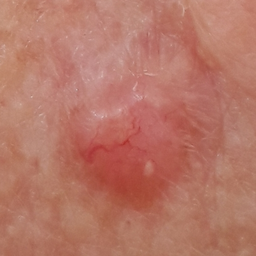

Segmented Image:


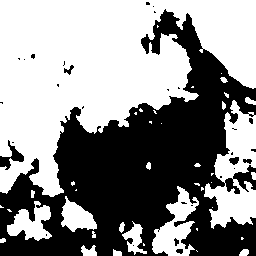

In [44]:
import cv2
from google.colab.patches import cv2_imshow

# Load the image example image of a lesion
image_path = "sample_images/NEV_23.png"  # Update this path to your sample image
image = cv2.imread(image_path)

# Convert to grayscale and apply blur
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Apply thresholding with Otsu's method
_, thresh_image = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display results
print("Original Image:")
cv2_imshow( image)
print("Segmented Image:")
cv2_imshow(thresh_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [45]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern

def extract_features(image, mask):
    # --- 1. Edge features ---
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray_image, 50, 150)
    edge_count = edges.sum() / 255  # scalar

    # --- 2. Shape features ---
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    roundness = 4 * np.pi * area / (perimeter**2 + 1e-6)  # avoid division by zero

    # --- 3. Color features ---
    mean_color = image.mean(axis=(0,1))      # 3 features
    std_color  = image.std(axis=(0,1))       # 3 features

    # --- 4. Texture features LBP  ---
    lbp = local_binary_pattern(gray_image, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 10), density=True)

    # --- 5. Stack all features into one flat vector ---
    feature_vector = np.hstack([
        edge_count,            # 1
        area, perimeter, roundness,  # 3
        mean_color,            # 3
        std_color,             # 3
        lbp_hist               # 9
        # hog_features         # optional
    ])

    return feature_vector
# mask is the 
image_features = extract_features(image, thresh_image)
display(image_features)


array([2.87000000e+02, 2.79965000e+04, 1.58695749e+03, 1.39695693e-01,
       1.03163101e+02, 1.18465637e+02, 1.81857986e+02, 1.70013632e+01,
       1.68606695e+01, 8.71164102e+00, 4.67681885e-02, 6.79779053e-02,
       6.27441406e-02, 1.15524292e-01, 1.42822266e-01, 1.36993408e-01,
       1.01638794e-01, 8.68988037e-02, 2.38632202e-01])

In [46]:
# compute image features for all images in the dataset and store them in a new dataframe
def build_feature_data(imgs, extract_features, feature_names):
    extracted_features = []
    for idx in range(len(imgs)):
        img = imgs[idx]
        gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
        # Apply thresholding with Otsu's method
        _, thresh_image = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        mask = thresh_image  
        features = extract_features(img, mask)
        # Store features in a new dataframe or array as needed 
        extracted_features.append(features)
        if (idx + 1) % 300 == 0 or idx == len(imgs) - 1:
            print(f"Extracted features for image {idx+1}/{len(imgs)}")
        
    return pd.DataFrame(extracted_features, columns=feature_names)

In [47]:
# visulaize the mean of all featrues across the different lesion types

feature_names = [
    "edge_count",
    "area", "perimeter", "roundness",
    "mean_B", "mean_G", "mean_R",
    "std_B", "std_G", "std_R",
    "lbp_bin_0", "lbp_bin_1", "lbp_bin_2", "lbp_bin_3", "lbp_bin_4",
    "lbp_bin_5", "lbp_bin_6", "lbp_bin_7", "lbp_bin_8"
]

# Convert list of feature vectors into a DataFrame
df = build_feature_data(imgs, extract_features, feature_names)
# Add the lesion type column
df['lesion_type'] = y_dev["fine_label"].values

# Compute mean feature values per class
class_means = df.groupby('lesion_type').mean()

print(class_means)



Extracted features for image 300/1178
Extracted features for image 600/1178
Extracted features for image 900/1178
Extracted features for image 1178/1178
              edge_count          area    perimeter  roundness      mean_B  \
lesion_type                                                                  
ACK          7871.151376  29243.809633  1704.234529   0.160285  168.300201   
BCC          7297.408284  33465.796598  1783.347247   0.185748  171.591731   
MEL          5126.439024  50624.658537  1412.304048   0.457496  162.460246   
NEV          2929.192982  50220.561404  1400.576049   0.439205  162.616702   
SCC          7529.948052  31376.516234  1849.786949   0.158089  167.421759   
SEK          7339.562500  42547.156250  1876.587400   0.234282  164.809834   

                 mean_G      mean_R      std_B      std_G      std_R  \
lesion_type                                                            
ACK          130.402349  114.267904  23.943051  26.083689  26.264525   
BCC   

In [48]:
#extend the features with the newly extracted features. This will be the final feature set that we will use for training our model.
X_dev_final = pd.concat([X_dev.reset_index(drop=True), df.drop(columns=['lesion_type'])], axis=1)
X_dev_final

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation,background_father_AUSTRIA,background_father_BRASIL,background_father_BRAZIL,background_father_CZECH,background_father_GERMANY,background_father_ISRAEL,background_father_ITALY,background_father_NETHERLANDS,background_father_POLAND,background_father_POMERANIA,background_father_PORTUGAL,background_father_SPAIN,background_father_UNK,background_mother_BRAZIL,background_mother_GERMANY,background_mother_ITALY,background_mother_NETHERLANDS,background_mother_NORWAY,background_mother_POLAND,background_mother_POMERANIA,background_mother_PORTUGAL,background_mother_SPAIN,background_mother_UNK,region_ABDOMEN,region_ARM,region_BACK,region_CHEST,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH,no_itch,no_grew,no_hurt,no_changed,edge_count,area,perimeter,roundness,mean_B,mean_G,mean_R,std_B,std_G,std_R,lbp_bin_0,lbp_bin_1,lbp_bin_2,lbp_bin_3,lbp_bin_4,lbp_bin_5,lbp_bin_6,lbp_bin_7,lbp_bin_8
0,PAT_620,PAT_620_001,0,0,55,0,1,1,1,1,1,3.0,6.0,5.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0,1033.0,34047.5,1334.447825,0.240266,164.455200,131.600891,128.725342,13.827750,21.668840,25.263227,0.061493,0.082886,0.065552,0.099762,0.124298,0.124847,0.100143,0.091385,0.249634
1,PAT_388,PAT_388_002,0,1,79,0,0,1,0,0,0,1.0,5.0,5.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1,2726.0,36428.0,2391.699694,0.080026,141.170731,114.399811,102.130722,14.268699,18.281030,18.465258,0.038620,0.059769,0.058212,0.133835,0.193405,0.151245,0.089020,0.078873,0.197021
2,PAT_518,PAT_518_003,0,1,52,0,1,0,1,1,1,3.0,15.0,10.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,0,15547.0,12638.0,2143.949474,0.034551,227.432755,180.546112,153.288834,12.082949,18.590016,22.089448,0.089569,0.090561,0.074265,0.089813,0.101837,0.090942,0.079056,0.102905,0.281052
3,PAT_635,PAT_635_004,0,0,74,1,1,0,0,0,0,1.0,15.0,10.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,3268.0,59977.0,1833.141257,0.224286,156.927490,150.475845,145.365112,11.291585,16.961407,14.955407,0.031464,0.045990,0.066727,0.157471,0.226425,0.174011,0.095459,0.058945,0.143509
4,PAT_447,PAT_447_005,0,1,58,1,1,1,1,1,1,1.0,9.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,1,3122.0,44281.0,1441.719904,0.267711,158.891495,138.777481,135.200989,22.398916,25.774490,31.113438,0.050583,0.073196,0.069855,0.125519,0.157928,0.143707,0.097656,0.082932,0.198624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1173,PAT_409,PAT_409_1470,1,0,66,0,0,1,0,1,1,2.0,20.0,15.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,1,13926.0,28856.0,2136.552505,0.079436,173.707932,131.791397,115.803909,20.586186,23.378213,21.812994,0.058685,0.073212,0.078079,0.127930,0.149506,0.132919,0.100464,0.079498,0.199707
1174,PAT_640,PAT_640_1471,0,0,4

In [49]:
# Extend test set to final version
X_test = pd.read_csv("x_test.csv")  # Load test set metadata
test_imgs_path = "x_test_img.npz"
test_imgs, img_ids = load_img_data(test_imgs_path)
X_test = convert_to_binary(X_test, categorical_cols, 'gender', {'MALE': 0, 'FEMALE': 1})
X_test = create_no_response_column(X_test, ['itch', 'grew', 'hurt', 'changed'])
X_test_extracted = build_feature_data(test_imgs, extract_features, feature_names)
X_test_final = pd.concat([X_test.reset_index(drop=True), X_test_extracted], axis=1)
display(X_test_final)


Successfully loaded 296 images.
Automatically converting itch to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting grew to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting hurt to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting changed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Automatically converting bleed to binary...
The following values are being mapped to NaN in this column:  ['UNK']
Extracted features for image 296/296


,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation,background_father_BRASIL,background_father_BRAZIL,background_father_GERMANY,background_father_ITALY,background_father_NETHERLANDS,background_father_POLAND,background_father_POMERANIA,background_father_PORTUGAL,background_father_UNK,background_mother_BRAZIL,background_mother_FRANCE,background_mother_GERMANY,background_mother_ITALY,background_mother_NETHERLANDS,background_mother_POLAND,background_mother_POMERANIA,background_mother_PORTUGAL,background_mother_SPAIN,background_mother_UNK,region_ABDOMEN,region_ARM,region_BACK,region_CHEST,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH,no_itch,no_grew,no_hurt,no_changed,edge_count,area,perimeter,roundness,mean_B,mean_G,mean_R,std_B,std_G,std_R,lbp_bin_0,lbp_bin_1,lbp_bin_2,lbp_bin_3,lbp_bin_4,lbp_bin_5,lbp_bin_6,lbp_bin_7,lbp_bin_8
0,PAT_667,PAT_667_275,0,0,71,0,0,1,0,0,0,3.0,5.0,4.0,1.0,1.0,1.0,0.0,1.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,1,4424.0,42882.0,2207.782953,0.110553,172.326385,121.066132,119.852081,22.718534,26.136898,27.774467,0.069275,0.075500,0.068253,0.110016,0.137131,0.119080,0.083649,0.083420,0.253677
1,PAT_736,PAT_736_156,0,0,51,1,0,1,1,0,0,2.0,35.0,27.0,1.0,0.0,1.0,0.0,0.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,1,4822.0,25635.0,2388.483523,0.056468,118.157272,111.464798,105.565811,15.910918,19.020719,20.960762,0.065567,0.074936,0.079575,0.120972,0.132965,0.116180,0.085617,0.084137,0.240051
2,PAT_628,PAT_628_085,1,0,58,1,1,0,0,0,0,3.0,3.0,2.0,0.0,1.0,0.0,0.0,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0,1,1,11696.0,28912.5,1707.810304,0.124571,196.919342,147.411224,113.943405,40.045498,38.661782,37.805237,0.054581,0.064270,0.076920,0.139328,0.172623,0.141937,0.090088,0.070496,0.189758
3,PAT_461,PAT_461_083,0,0,80,0,0,0,1,1,1,3.0,10.0,6.0,1.0,1.0,1.0,0.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,12501.0,19388.5,1601.207270,0.095030,159.654800,114.614883,72.997223,29.316677,35.137358,30.161757,0.079300,0.079376,0.072632,0.092117,0.132568,0.106796,0.072342,0.084732,0.280136
4,PAT_059,PAT_059_262,0,0,38,0,0,0,0,0,0,2.0,10.0,8.0,1.0,1.0,1.0,0.0,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,6592.0,64958.5,1049.698484,0.740827,225.655960,170.571732,145.470444,8.216590,34.252986,32.101686,0.067078,0.074402,0.071198,0.111191,0.151276,0.119263,0.085083,0.082870,0.237640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,PAT_307,PAT_307_189,0,0,75,0,1,1,1,1,1,2.0,10.0,9.0,1.0,0.0,0.0,0.0,0.0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,0,13102.0,17274.5,2506.348528,0.034557,176.930649,116.637909,89.028168,13.457003,21.975785,24.758250,0.078186,0.083786,0.073761,0.101669,0.131500,0.103943,0.080109,0.090057,0.256989
292,PAT_321,PAT_321_072,0,0,71,0,1,0,1,1,1,2.0,11.0,10.0,1.0,0.0,1.0,0.0,1.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0,0,0,7021.0,39678.5,2406.760656,0.086079,221.

## Data Analysis of ditribution:

- age distribution over complete dataset compare to test
- age distribution over each class
- patient_ids occurences if yes which classes(we probably take the mean if classes do not differ) compare to test
- lesion_ids have patients more lesions compare to test
- gender ditribution over complete dataset compare to test
- gender distribution over each class



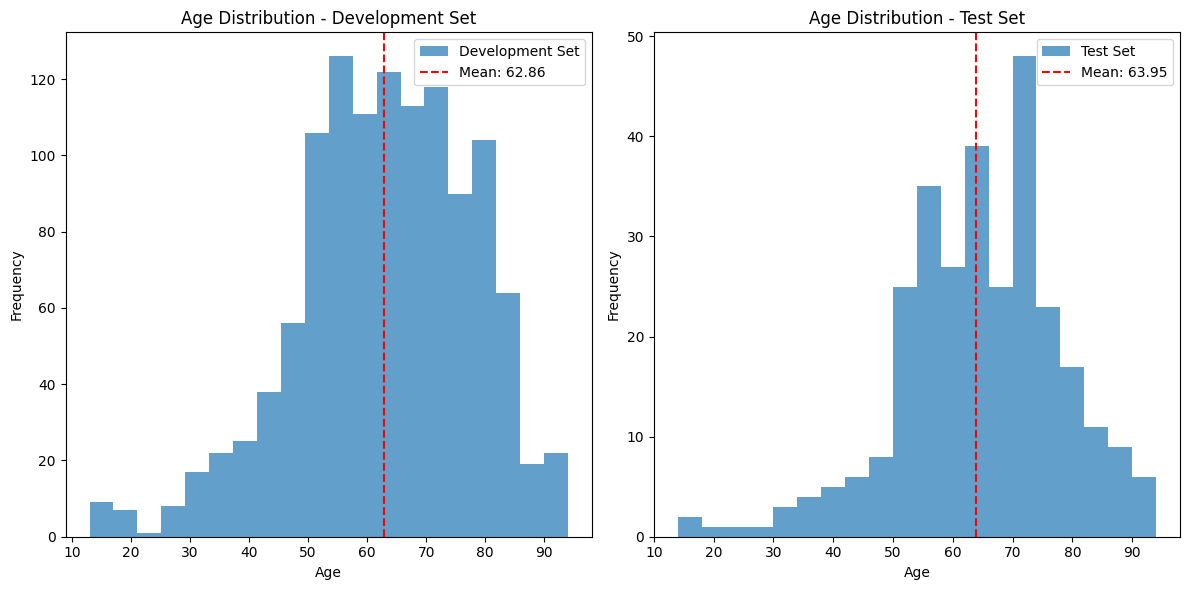

In [50]:
#------------------AGE DISTRIBUTION------------------
# plot age distribution across development set and test set
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(X_dev['age'], bins=20, alpha=0.7, label='Development Set')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution - Development Set')
mean = X_dev['age'].mean()
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
plt.legend()



plt.subplot(1, 2, 2)
plt.hist(X_test['age'], bins=20, alpha=0.7, label='Test Set')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution - Test Set')
mean = X_test['age'].mean()
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
plt.legend()

plt.tight_layout()
plt.show()



Text(0.5, 0, 'Age')

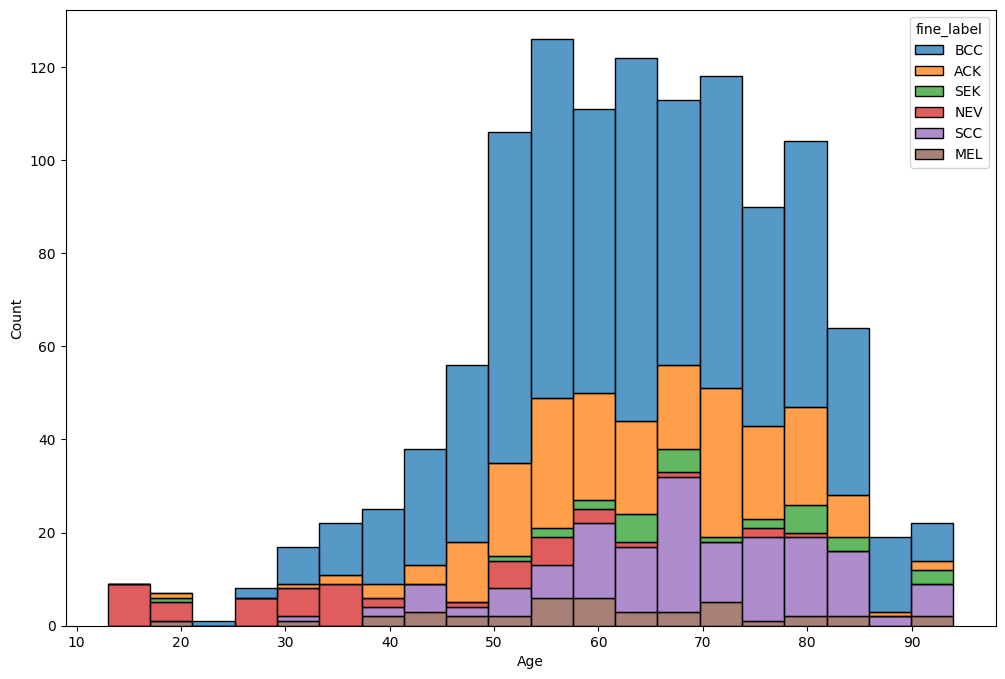

In [51]:
#------------------AGE DISTRIBUTION each class------------------
plt.figure(figsize=(12, 8))
sns.histplot(data=X_dev, x='age', hue=y_dev['fine_label'], multiple='stack', bins=20)
plt.xlabel('Age')


In [52]:
# print all patient ids that occure more thatn once in the development set
dev_ids = X_dev['patient_id'].value_counts()
dev_ids = dev_ids[dev_ids > 1]
print("Patient IDs occurring more than once in the development set:")
print(dev_ids.index.tolist())


#print all patient ids that occur more than once in the test set
test_ids = X_test['patient_id'].value_counts()
test_ids = test_ids[test_ids > 1]
print("Patient IDs occurring more than once in the test set:")
print(len(test_ids.index.tolist()))

#check weather the patients have different lesions check fine labels are the same for the same patient id
#report all patients that have different fine labels in the development set
#get column names
y_dev = pd.read_csv(y_file)
dev_patient_lesions = y_dev.groupby('patient_id')['fine_label'].nunique()
dev_multi_lesion_patients = dev_patient_lesions[dev_patient_lesions > 1]
print("Patients with multiple fine labels in the development set:")
print(len(dev_multi_lesion_patients.index.tolist()))

Patient IDs occurring more than once in the development set:
['PAT_226', 'PAT_252', 'PAT_527', 'PAT_603', 'PAT_510', 'PAT_778', 'PAT_620', 'PAT_653', 'PAT_577', 'PAT_251', 'PAT_332', 'PAT_347', 'PAT_456', 'PAT_400', 'PAT_781', 'PAT_292', 'PAT_068', 'PAT_773', 'PAT_101', 'PAT_568', 'PAT_629', 'PAT_070', 'PAT_309', 'PAT_769', 'PAT_558', 'PAT_409', 'PAT_707', 'PAT_477', 'PAT_287', 'PAT_062', 'PAT_687', 'PAT_257', 'PAT_388', 'PAT_108', 'PAT_174', 'PAT_698', 'PAT_532', 'PAT_684', 'PAT_534', 'PAT_425', 'PAT_659', 'PAT_420', 'PAT_387', 'PAT_280', 'PAT_771', 'PAT_701', 'PAT_085', 'PAT_793', 'PAT_036', 'PAT_575', 'PAT_319', 'PAT_533', 'PAT_197', 'PAT_611', 'PAT_638', 'PAT_548', 'PAT_386', 'PAT_243', 'PAT_320', 'PAT_454', 'PAT_057', 'PAT_241', 'PAT_416', 'PAT_487', 'PAT_547', 'PAT_465', 'PAT_549', 'PAT_154', 'PAT_022', 'PAT_215', 'PAT_476', 'PAT_041', 'PAT_310', 'PAT_049', 'PAT_350', 'PAT_023', 'PAT_130', 'PAT_453', 'PAT_366', 'PAT_537', 'PAT_737', 'PAT_167', 'PAT_471', 'PAT_143', 'PAT_333', 'PA

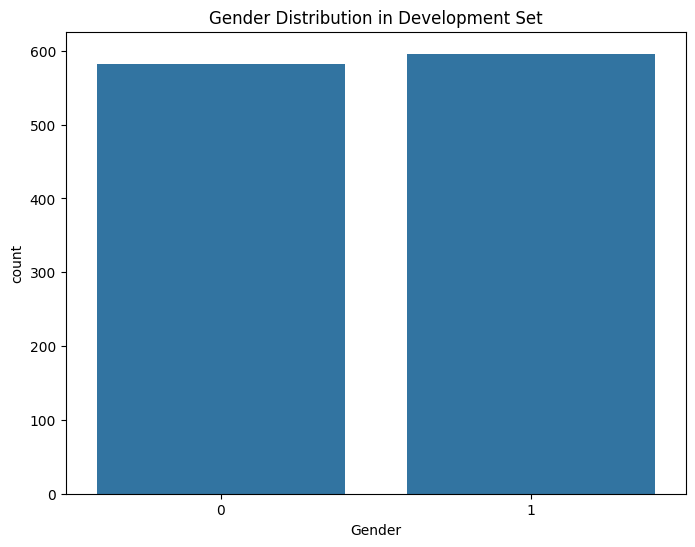

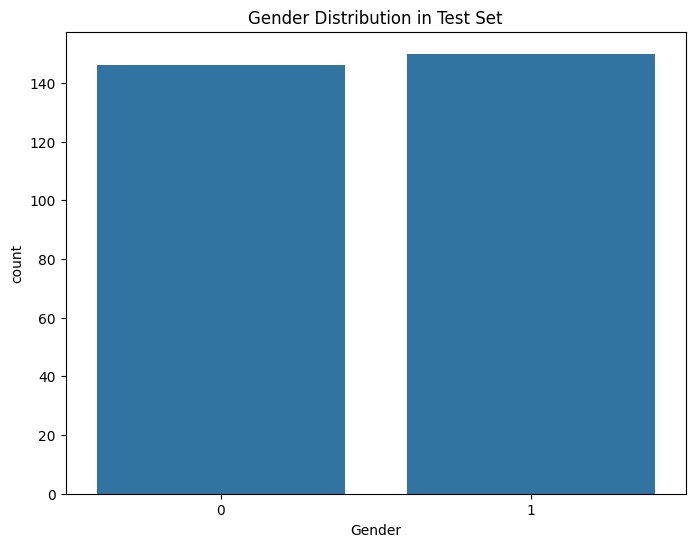

In [53]:
# ----------------Gender distribution------------------
plt.figure(figsize=(8, 6))
sns.countplot(x=X_dev['gender'])
plt.xlabel('Gender')
plt.title('Gender Distribution in Development Set')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x=X_test['gender'])
plt.xlabel('Gender')
plt.title('Gender Distribution in Test Set')
plt.show()

### Conclusion:
The datasets are very similar and representative, the Cross valdiation has to satisfy the following:
- there should be no patient from the train set in the validation set
- there should be an equal distribution of lesion classes and age in the validation set(maintaining the original structure)
- each lesion has exactly one diagnosis, each lesion may have multiple images
- but a patient may have many lesions with different diagnoses, which is why we have to group by lesion not by patient

## Cross Validation
- construct folds manually since skit learn can only handle Grouping or stratisfaction

In [54]:
#Build Patient-Level table
#Columns: Patient ID, fine_label, age bin, number of leesions
#Group by lesion type
df_crossval = X_dev_final.merge(y_dev[['img_id', 'fine_label']], on='img_id', how='left')
lesions = (
    df_crossval.groupby("img_id")
      .agg({
          "patient_id": "first",
          "fine_label": "first",
          "age": "first"
      })
      .reset_index()
)

#Use the same age bins as specifided earlier
lesions["age_bin"] = age_groups
lesions["strat_label"] = (
    lesions["fine_label"].astype(str) + "_" + lesions["age_bin"].astype(str)
)

import numpy as np
K = 5
lesions["fold"] = -1

# shuffle for reproducibility
lesions = lesions.sample(frac=1, random_state=42).reset_index(drop=True)

# group lesions by patient
patient_groups = lesions.groupby("patient_id")

# track fold loads
fold_counts = np.zeros(K, dtype=int)

for patient_id, group in patient_groups:
    # choose fold with smallest load
    f = np.argmin(fold_counts)
    lesions.loc[group.index, "fold"] = f
    fold_counts[f] += len(group)
df_crossval = df_crossval.merge(lesions[["img_id", "fold"]], on="img_id", how="left")

for f in range(K):
    sub = df_crossval[df_crossval["fold"] == f]
    print(f"Fold {f}")
    print(sub["age"].describe())
    print(sub["fine_label"].value_counts(normalize=True))
    print()


Fold 0
count    236.000000
mean      65.008475
std       13.509962
min       21.000000
25%       55.000000
50%       66.000000
75%       77.000000
max       90.000000
Name: age, dtype: float64
fine_label
BCC    0.580508
ACK    0.186441
SCC    0.072034
MEL    0.072034
NEV    0.059322
SEK    0.029661
Name: proportion, dtype: float64

Fold 1
count    235.000000
mean      62.080851
std       13.143434
min       20.000000
25%       55.000000
50%       62.000000
75%       71.000000
max       90.000000
Name: age, dtype: float64
fine_label
BCC    0.582979
ACK    0.182979
SCC    0.148936
NEV    0.034043
MEL    0.029787
SEK    0.021277
Name: proportion, dtype: float64

Fold 2
count    235.000000
mean      61.051064
std       15.437963
min       14.000000
25%       52.000000
50%       61.000000
75%       72.500000
max       91.000000
Name: age, dtype: float64
fine_label
BCC    0.548936
ACK    0.174468
SCC    0.144681
NEV    0.063830
MEL    0.046809
SEK    0.021277
Name: proportion, dtype: float64

In [55]:
# add the fold column to the original X_dev_final dataframe for later use in training and validation splits
fold_map = df_crossval.set_index("img_id")["fold"]
X_dev_final["fold"] = X_dev_final["img_id"].map(fold_map)

#check if all folds are assigned correctly
X_dev_final['fold'].isna().sum()
display(X_dev_final.head())

,patient_id,img_id,smoke,drink,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,has_sewage_system,fitspatrick,diameter_1,diameter_2,itch,grew,hurt,changed,bleed,elevation,background_father_AUSTRIA,background_father_BRASIL,background_father_BRAZIL,background_father_CZECH,background_father_GERMANY,background_father_ISRAEL,background_father_ITALY,background_father_NETHERLANDS,background_father_POLAND,background_father_POMERANIA,background_father_PORTUGAL,background_father_SPAIN,background_father_UNK,background_mother_BRAZIL,background_mother_GERMANY,background_mother_ITALY,background_mother_NETHERLANDS,background_mother_NORWAY,background_mother_POLAND,background_mother_POMERANIA,background_mother_PORTUGAL,background_mother_SPAIN,background_mother_UNK,region_ABDOMEN,region_ARM,region_BACK,region_CHEST,region_EAR,region_FACE,region_FOOT,region_FOREARM,region_HAND,region_LIP,region_NECK,region_NOSE,region_SCALP,region_THIGH,no_itch,no_grew,no_hurt,no_changed,edge_count,area,perimeter,roundness,mean_B,mean_G,mean_R,std_B,std_G,std_R,lbp_bin_0,lbp_bin_1,lbp_bin_2,lbp_bin_3,lbp_bin_4,lbp_bin_5,lbp_bin_6,lbp_bin_7,lbp_bin_8,fold
0,PAT_620,PAT_620_001,0,0,55,0,1,1,1,1,1,3.0,6.0,5.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,1,0,1033.0,34047.5,1334.447825,0.240266,164.455200,131.600891,128.725342,13.827750,21.668840,25.263227,0.061493,0.082886,0.065552,0.099762,0.124298,0.124847,0.100143,0.091385,0.249634,1
1,PAT_388,PAT_388_002,0,1,79,0,0,1,0,0,0,1.0,5.0,5.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1,1,2726.0,36428.0,2391.699694,0.080026,141.170731,114.399811,102.130722,14.268699,18.281030,18.465258,0.038620,0.059769,0.058212,0.133835,0.193405,0.151245,0.089020,0.078873,0.197021,2
2,PAT_518,PAT_518_003,0,1,52,0,1,0,1,1,1,3.0,15.0,10.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,0,15547.0,12638.0,2143.949474,0.034551,227.432755,180.546112,153.288834,12.082949,18.590016,22.089448,0.089569,0.090561,0.074265,0.089813,0.101837,0.090942,0.079056,0.102905,0.281052,4
3,PAT_635,PAT_635_004,0,0,74,1,1,0,0,0,0,1.0,15.0,10.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,1,3268.0,59977.0,1833.141257,0.224286,156.927490,150.475845,145.365112,11.291585,16.961407,14.955407,0.031464,0.045990,0.066727,0.157471,0.226425,0.174011,0.095459,0.058945,0.143509,3
4,PAT_447,PAT_447_005,0,1,58,1,1,1,1,1,1,1.0,9.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,1,3122.0,44281.0,1441.719904,0.267711,158.891495,138.777481,135.200989,22.398916,25.774490,31.113438,0.050583,0.073196,0.069855,0.125519,0.157928,0.143707,0.097656,0.082932,0.198624,4


## Test set evaluation
- the dev set includes calsses that are not present in the test set and vice versa
- the test and development set should have exact same classes

In [56]:
# 0. Make a copy so the original stays untouched
X_test_new_final = X_test_final.copy()

# 1. Identify columns (as sets, excluding 'fold' from the dev side)
train_cols_no_fold = set(X_dev_final.columns) - {"fold"}
test_cols = set(X_test_new_final.columns)

print("Columns in training set and not in test set BEFORE alignment:", train_cols_no_fold - test_cols)
print("Columns in test set and not in training set BEFORE alignment:", test_cols - train_cols_no_fold)

# 2. Add missing train columns to test set (fill with 0)
missing_in_test = train_cols_no_fold - test_cols
for col in missing_in_test:
    X_test_new_final[col] = 0

# 3. Drop columns that appear in test but not in train
test_cols_after_add = set(X_test_new_final.columns)
extra_in_test = test_cols_after_add - train_cols_no_fold
X_test_new_final = X_test_new_final.drop(columns=list(extra_in_test))

# 4. Reindex test set to match train column order (excluding fold)
X_test_new_final = X_test_new_final.reindex(columns=[c for c in X_dev_final.columns if c != "fold"])

# 5. Sanity check after alignment
final_train_cols = set(X_dev_final.columns) - {"fold"}
final_test_cols = set(X_test_new_final.columns)

print("Columns in training set and not in test set AFTER alignment:", final_train_cols - final_test_cols)
print("Columns in test set and not in training set AFTER alignment:", final_test_cols - final_train_cols)

# 6. Save files
X_test_new_final.to_csv("X_test_final.csv", index=False)
X_dev_final.to_csv("X_dev_final.csv", index=False)


Columns in training set and not in test set BEFORE alignment: {'background_father_AUSTRIA', 'background_father_SPAIN', 'background_father_ISRAEL', 'background_father_CZECH', 'background_mother_NORWAY'}
Columns in test set and not in training set BEFORE alignment: {'background_mother_FRANCE'}
Columns in training set and not in test set AFTER alignment: set()
Columns in test set and not in training set AFTER alignment: set()
